#### Time Series of Aggregate Water Use 

Creates time series figure of aggregate water use for each watershed and water use type (e.g. public supply, irrigation) by scenario. NB: this figure is for US side of watershed only as validation data only covers US side. 
\
\
Currently missing modeled thermoelectric data.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# get filepath 
cd = Path.cwd() 

# create folder to store clean data 
out_dir = Path(f"{cd}/Figures")
out_dir.mkdir(parents=True, exist_ok=True)

In [2]:
##### ---------- MANUAL SET UP ----------

# for each scenario you want included in the figure, set scenario name, run date,
# plot color, and legend label for each watershed
scenarios = [
    {
        'scenario': 'calibration',
        'run_dates': {
            'GBSJ': '2026-07-16',
            'LCRR': '2026-07-16',
            'MILK': '2026-07-16',
        },
        'color': '#1f77b4',   # muted blue
        'label': 'Calibration',
    },
]

In [3]:
##### ---------- PREP DATA ----------

def prep_data(watershed, scenarios):

    ### ----- PREP USGS VALIDATION DATA -----
    USGS_data = pd.read_csv(f"{cd}/Clean_Data/{watershed}/USGS_validation.csv")
    USGS_data.loc[USGS_data["Watershed"] == "GBSJ", "in_us"] = 1
    USGS_data = USGS_data[USGS_data["in_us"] != 0]

    USGS_data_aggregate = (
        USGS_data
        .groupby('Year')[
            ['public_supply_mil_gal_validation', 'irrigation_mil_gal_validation', 'thermo_consumptive_million_gal_validation']
        ]
        .sum()
        .reset_index()
    )

    data_for_fig = USGS_data_aggregate

    ### ----- LOOP OVER SCENARIOS, MERGE EACH ONE IN -----
    all_regions = pd.read_csv('/netfiles/ciroh/cmanitiu/USGS/Data_final/Basin_Boundaries/US_region_list.csv')
    all_regions = all_regions.rename(columns={'huc12': 'HUC12'})

    for s in scenarios:
        scenario = s['scenario']
        run_date = s['run_dates'][watershed]

        # load data
        model_data = pd.read_csv(f"{cd}/Clean_Data/{watershed}/{scenario}-{run_date}.csv")

        # filter out non-US HUCs
        model_data = model_data.merge(all_regions, on='HUC12', how='left')
        model_data.loc[model_data["Watershed"] == "GBSJ", "in_us"] = 1
        model_data = model_data[model_data["in_us"] != 0]

        # sum by year and run_ID
        model_data_aggregate = (
            model_data
            .groupby(['Year', 'run_ID'])[
                [f'public_supply_mil_gal_{scenario}', f'irrigation_mil_gal_{scenario}']
            ]
            .sum()
            .reset_index()
        )

        # get mean, 5th, and 95th percentile values for each year
        value_cols = [f'public_supply_mil_gal_{scenario}', f'irrigation_mil_gal_{scenario}']
        model_data_percentiles = (
            model_data_aggregate
            .groupby('Year')[value_cols]
            .agg(['mean', lambda x: x.quantile(0.05), lambda x: x.quantile(0.95)])
        )
        model_data_percentiles.columns = [
            f"{col}_{stat}" for col, stat in
            zip(model_data_percentiles.columns.get_level_values(0), ['mean', 'p05', 'p95'] * len(value_cols))
        ]
        model_data_percentiles = model_data_percentiles.reset_index()

        # merge this scenario's columns into the growing data_for_fig
        data_for_fig = data_for_fig.merge(model_data_percentiles, on='Year', how='outer')

    return data_for_fig

### ----- RUN FOR EACH WATERSHED -----

watersheds = ['GBSJ', 'LCRR', 'MILK']
data_for_fig = {w: prep_data(w, scenarios) for w in watersheds}

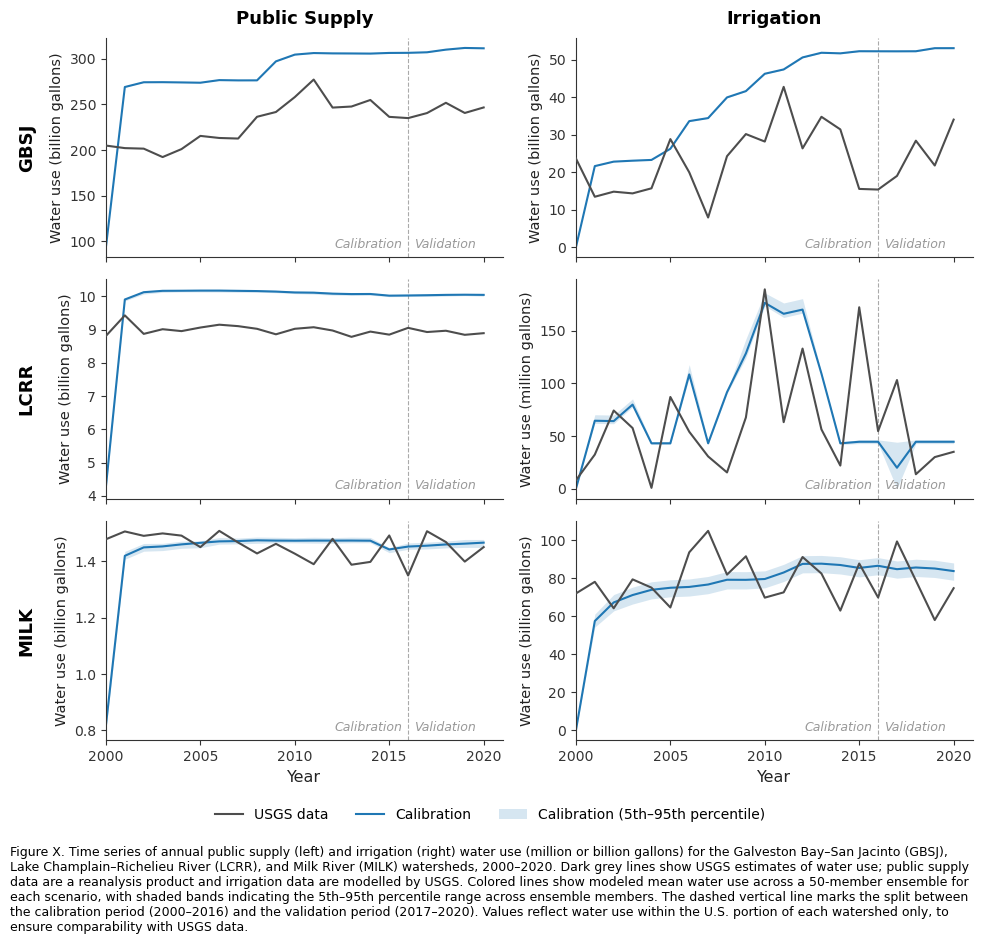

In [4]:
##### ---------- GENERATE FIGURE ----------

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11,
    'axes.linewidth': 0.8,
    'axes.edgecolor': '#333333',
    'axes.labelcolor': '#222222',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

watersheds = ['GBSJ', 'LCRR', 'MILK']
water_use_types = [
    ('public_supply', 'Public Supply'),
    ('irrigation', 'Irrigation'),
]

scenario_names = [s['scenario'] for s in scenarios]


def get_scale(df, use_key, scenarios):
    """Determine whether to plot in million or billion gallons based on max value."""
    cols = []
    obs_col = f'{use_key}_mil_gal_validation'
    if obs_col in df.columns:
        cols.append(obs_col)
    for s in scenarios:
        scenario = s['scenario']
        for suffix in ['mean', 'p05', 'p95']:
            c = f'{use_key}_mil_gal_{scenario}_{suffix}'
            if c in df.columns:
                cols.append(c)
    if not cols:
        return 1, 'million gallons'
    max_val = df[cols].max().max()
    if max_val >= 1000:
        return 1000, 'billion gallons'
    return 1, 'million gallons'


fig, axes = plt.subplots(
    nrows=3, ncols=2, figsize=(10, 9.5), sharex=True
)

for row, watershed in enumerate(watersheds):
    df = data_for_fig[watershed]

    for col, (use_key, use_label) in enumerate(water_use_types):
        ax = axes[row, col]

        # ----- determine unit scale for this panel -----
        scale, unit = get_scale(df, use_key, scenarios)

        # ----- observed (validation) line -----
        obs_col = f'{use_key}_mil_gal_validation'
        if obs_col in df.columns:
            ax.plot(
                df['Year'], df[obs_col] / scale,
                color='#4d4d4d', linewidth=1.5, label='USGS data', zorder=3
            )

        # ----- scenario mean + uncertainty band -----
        for s in scenarios:
            scenario = s['scenario']
            color = s['color']
            label = s['label']

            mean_col = f'{use_key}_mil_gal_{scenario}_mean'
            p05_col = f'{use_key}_mil_gal_{scenario}_p05'
            p95_col = f'{use_key}_mil_gal_{scenario}_p95'

            if mean_col not in df.columns:
                continue

            ax.plot(
                df['Year'], df[mean_col] / scale,
                color=color, linewidth=1.5, label=label, zorder=2
            )
            ax.fill_between(
                df['Year'], df[p05_col] / scale, df[p95_col] / scale,
                color=color, alpha=0.18, linewidth=0, zorder=1,
                label=f'{label} (5th–95th percentile)'
            )

        # ----- x axis starts at 2000, ticks every 5 years -----
        ax.set_xlim(left=2000)
        ax.xaxis.set_major_locator(mticker.MultipleLocator(5))

        # ----- calibration/validation divider at 2016 -----
        ax.axvline(2016, color='#aaaaaa', linewidth=0.8, linestyle='--', zorder=0)

        ax.text(2016 - 0.3, 0.03, 'Calibration', transform=ax.get_xaxis_transform(),
                 ha='right', va='bottom', fontsize=9, color='#999999', style='italic')
        ax.text(2016 + 0.3, 0.03, 'Validation', transform=ax.get_xaxis_transform(),
                 ha='left', va='bottom', fontsize=9, color='#999999', style='italic')

        # ----- titles -----
        if row == 0:
            ax.set_title(use_label, fontsize=13, fontweight='bold', pad=10)

        # ----- row label (watershed name), only on left column -----
        if col == 0:
            ax.text(-0.20, 0.5, watershed, transform=ax.transAxes,
                     rotation=90, va='center', ha='center',
                     fontsize=13, fontweight='bold')

        # ----- y axis label with correct unit for this panel -----
        ax.set_ylabel(f'Water use ({unit})', fontsize=10.5)

        if row == 2:
            ax.set_xlabel('Year', fontsize=11.5)

        ax.tick_params(axis='both', labelsize=10)

##### ---------- SHARED LEGEND ----------

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels, loc='lower center', ncol=4,   # 4 cols -> 2 rows instead of 3
    frameon=False, bbox_to_anchor=(0.5, 0.115), fontsize=10
)

##### ---------- CAPTION ----------

caption_text = (
    "Figure X. Time series of annual public supply (left) and irrigation (right) water use (million or billion gallons) for the Galveston Bay–San Jacinto (GBSJ),\n" 
    "Lake Champlain–Richelieu River (LCRR), and Milk River (MILK) watersheds, 2000–2020. Dark grey lines show USGS estimates of water use; public supply\n" 
    "data are a reanalysis product and irrigation data are modelled by USGS. Colored lines show modeled mean water use across a 50-member ensemble for\n" 
    "each scenario, with shaded bands indicating the 5th–95th percentile range across ensemble members. The dashed vertical line marks the split between\n" 
    "the calibration period (2000–2016) and the validation period (2017–2020). Values reflect water use within the U.S. portion of each watershed only, to\n"
    "ensure comparability with USGS data."
)

fig.text(
    0.02, 0.01,
    caption_text,
    ha='left', va='bottom', fontsize=9, wrap=True
)

# tighter bottom margin now that legend is 2 rows instead of 3
fig.tight_layout(rect=[0.02, 0.15, 1, 1])

# save
save_path = out_dir / "aggregate_water_use_timeseries.png"
fig.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()